In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("../data/raw/solbiato_products.csv")

In [3]:
df.head()

,product_name,category,product_type,collection,price,image_url,date_collected
0,CL-French Terry Hoodie Reflective,Adult,Hoodie,Solbiato Classic,155.0,NaN,2026-04
1,CL-French Terry Reflective Jogger,Adult,Pants,Solbiato Classic,95.0,NaN,2026-04
2,CL-SS Logo Polo,Adult,Polo,Solbiato Classic,115.0,NaN,2026-04
3,CL-Nylon Shorts,Adult,Shorts,Solbiato Classic,85.0,NaN,2026-04
4,Waa Pants,Adult,Pants,Solbiato Sport,62.5,NaN,2026-04


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_name    20 non-null     object 
 1   category        20 non-null     object 
 2   product_type    20 non-null     object 
 3   collection      20 non-null     object 
 4   price           20 non-null     float64
 5   image_url       0 non-null      float64
 6   date_collected  20 non-null     object 
dtypes: float64(2), object(5)
memory usage: 1.2+ KB


In [5]:
df.columns

Index(['product_name', 'category', 'product_type', 'collection', 'price',
       'image_url', 'date_collected'],
      dtype='object')

In [6]:
df.describe()

,price,image_url
count,20.000000,0.0
mean,62.837500,NaN
std,34.747044,NaN
min,20.000000,NaN
25%,39.000000,NaN
50%,56.000000,NaN
75%,86.000000,NaN
max,155.000000,NaN


In [7]:
df.isnull().sum()

product_name       0
category           0
product_type       0
collection         0
price              0
image_url         20
date_collected     0
dtype: int64

In [8]:
df['date_collected'] = pd.to_datetime(df['date_collected'])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   product_name    20 non-null     object        
 1   category        20 non-null     object        
 2   product_type    20 non-null     object        
 3   collection      20 non-null     object        
 4   price           20 non-null     float64       
 5   image_url       0 non-null      float64       
 6   date_collected  20 non-null     datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(4)
memory usage: 1.2+ KB


In [11]:
df.to_csv("../data/cleaned/solbiato_products.csv", index=False)

In [12]:
df['category'].value_counts()

category
Adult          9
Kids           7
Accessories    4
Name: count, dtype: int64

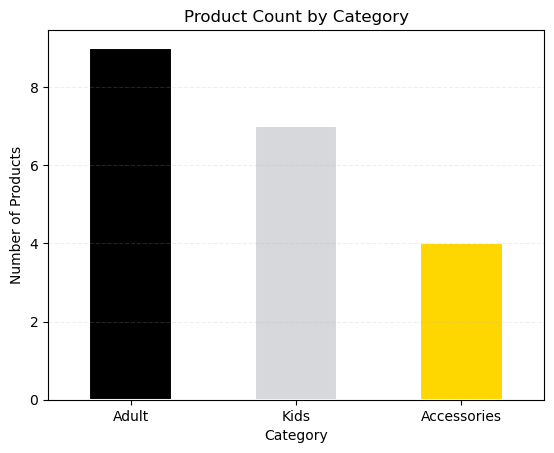

In [13]:
df['category'].value_counts().plot(
    kind='bar',
    color=['#000000', '#D6D8DC', '#FFD700'],
    edgecolor='#FFFFFF', 
    linewidth=1.5
)    

plt.title('Product Count by Category')
plt.xlabel('Category')
plt.ylabel('Number of Products')

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.2)

plt.show()


#### Webscraping (Selenium)

In [16]:
try:
    import selenium
    print(f"✅ Installed Selenium {selenium.__version__}")
except ImportError:
    print("Not Installed ❌")


✅ Installed Selenium 4.41.0


In [17]:
from selenium import webdriver

try:
    driver = webdriver.Chrome()
    print("✅ Chrome launched")
    
    # Testing Solbiato site
    driver.get("https://solbiatosport.com")
    print(f"Connected to: {driver.title}")
    
    driver.quit() 
except Exception as e:
    print(f"❌ Something went wrong: {e}")


✅ Chrome launched
Connected to: Home


In [21]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from bs4 import BeautifulSoup
import time
import pandas as pd

options = Options()
options.add_argument("--disable-blink-features=AutomationControlled")
options.add_experimental_option("excludeSwitches", ["enable-automation"])

driver = webdriver.Chrome(options=options)

try:
    # Trying to get to the homepage
    print("Opening Homepage")
    driver.get("https://solbiatosport.com")
    time.sleep(5) 

    # Trying to get to the Kids Category
    kids_url = "https://solbiatosport.com/product-category/solbiato-kids/"
    print(f"Heading to Kids: {kids_url}")
    driver.get(kids_url)
    time.sleep(8) 

    # Scrape Test
    if "solbiato-kids" in driver.current_url:
        print("✅ On the Kids page")
        
        driver.execute_script("window.scrollTo(0, 1000);")
        time.sleep(3)
        
        soup = BeautifulSoup(driver.page_source, 'html.parser')
        items = soup.find_all('div', class_='product-small')
        
        scraped_data = []
        for item in items:
            name = item.find(['p', 'h2', 'h3']).text.strip() if item.find(['p', 'h2', 'h3']) else "N/A"
            price = item.find('span', class_='woocommerce-Price-amount').text.strip() if item.find('span', class_='woocommerce-Price-amount') else "N/A"
            img = item.find('img')['src'] if item.find('img') else "N/A"
            
            scraped_data.append({
                'product_name': name,
                'category': 'Kids',
                'price': price,
                'image_url': img
            })
            
        df_kids = pd.DataFrame(scraped_data)
        print(f"Found {len(df_kids)} Kids products!")
        display(df_kids.head())
        df_kids.to_csv('../data/raw/scraped_kids_only.csv', index=False)
        
    else:
        print("❌ Redirected to Homepage. Site is blocking the scraper.")

finally:
    driver.quit()


Opening Homepage
Heading to Kids: https://solbiatosport.com/product-category/solbiato-kids/
✅ On the Kids page
Found 0 Kids products!


""


In [22]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# feed url
url = "https://solbiatosport.com/product-category/solbiato-kids/feed/"

headers = {
    'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}

print(f"Pulling Kids data from: {url}")
response = requests.get(url, headers=headers)

if response.status_code == 200:
    # Used 'xml'
    soup = BeautifulSoup(response.content, 'xml')
    items = soup.find_all('item')
    
    kids_products = []
    for item in items:
        name = item.find('title').text
    
        link = item.find('link').text
        
        kids_products.append({
            'product_name': name,
            'category': 'Kids',
            'url': link
        })
    
    df_kids = pd.DataFrame(kids_products)
    print(f"✅ Found {len(df_kids)} Kids products in the feed.")
    display(df_kids)
    
    # Saving to your raw folder
    df_kids.to_csv('../data/raw/scraped_kids_feed.csv', index=False)
else:
    print(f"❌ Failed. Status Code: {response.status_code}")


Pulling Kids data from: https://solbiatosport.com/product-category/solbiato-kids/feed/
✅ Found 10 Kids products in the feed.


,product_name,category,url
0,K-TOORA,Kids,https://solbiatosport.com/product/k-toora/
1,K-WARD,Kids,https://solbiatosport.com/product/k-ward/
2,K-TITANIC,Kids,https://solbiatosport.com/product/k-titanic/
3,K-BLOSSOM,Kids,https://solbiatosport.com/product/k-blossom/
4,K-SHOOKA,Kids,https://solbiatosport.com/product/k-shooka/
5,K-AJAR,Kids,https://solbiatosport.com/product/k-ajar/
6,K-STAMP,Kids,https://solbiatosport.com/product/k-stamp/
7,K-ZEPHYR,Kids,https://solbiatosport.com/product/k-zephyr/
8,K-JACK,Kids,https://solbiatosport.com/product/k-jack/
9,K-QUADRANT,Kids,https://solbiatosport.com/product/k-quadrant/


In [23]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

domain = "https://solbiatosport.com/"
path = "product-category/solbiato-kids/page/2/feed"
url = domain + path

headers = {'User-Agent': 'Mozilla/5.0'}

print(f" Pulling Page 2 data from: {url}")
response = requests.get(url, headers=headers)

if response.status_code == 200:
    soup = BeautifulSoup(response.content, 'xml')
    items = soup.find_all('item')
    
    kids_products = []
    for item in items:
        name = item.find('title').text
        link = item.find('link').text
    
        desc = item.find('description').text if item.find('description') else "N/A"
        
        kids_products.append({
            'product_name': name,
            'category': 'Kids',
            'price_info': desc,
            'url': link
        })
    
    df_kids_p2 = pd.DataFrame(kids_products)
    print(f"✅ Found {len(df_kids_p2)} more products.")
    display(df_kids_p2) 
    
    df_kids_p2.to_csv('../data/raw/scraped_kids_p2.csv', index=False)
else:
    print(f"❌ Failed. Status: {response.status_code}")


 Pulling Page 2 data from: https://solbiatosport.com/product-category/solbiato-kids/page/2/feed
❌ Failed. Status: 404


In [24]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# The specific Kids Feed URL
url = "https://solbiatosport.com/product-category/solbiato-kids/feed/"

headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)'}

print(f"Pulling Final Kids Data...")
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.content, 'xml')
items = soup.find_all('item')

kids_data = []
for item in items:
    name = item.find('title').text
    
    desc = item.find('description').text
    
    price = desc.split('$')[-1].split('<')[0] if '$' in desc else "N/A"
    
    kids_data.append({
        'product_name': name,
        'category': 'Kids',
        'price': price,
        'url': item.find('link').text
    })

df_final = pd.DataFrame(kids_data)
print(f"✅ Found {len(df_final)} products with prices.")
display(df_final)

# Saving
df_final.to_csv('../data/cleaned/solbiato_kids_final.csv', index=False)


Pulling Final Kids Data...
✅ Found 10 products with prices.


,product_name,category,price,url
0,K-TOORA,Kids,N/A,https://solbiatosport.com/product/k-toora/
1,K-WARD,Kids,N/A,https://solbiatosport.com/product/k-ward/
2,K-TITANIC,Kids,N/A,https://solbiatosport.com/product/k-titanic/
3,K-BLOSSOM,Kids,N/A,https://solbiatosport.com/product/k-blossom/
4,K-SHOOKA,Kids,N/A,https://solbiatosport.com/product/k-shooka/
5,K-AJAR,Kids,N/A,https://solbiatosport.com/product/k-ajar/
6,K-STAMP,Kids,N/A,https://solbiatosport.com/product/k-stamp/
7,K-ZEPHYR,Kids,N/A,https://solbiatosport.com/product/k-zephyr/
8,K-JACK,Kids,N/A,https://solbiatosport.com/product/k-jack/
9,K-QUADRANT,Kids,N/A,https://solbiatosport.com/product/k-quadrant/


In [25]:
import requests
from bs4 import BeautifulSoup
import pandas as pd


url = "https://solbiatosport.com/product-category/solbiato-kids/feed/?paged=2"
headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)'}

print(f"Pulling Page 2 Kids Data...")
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.content, 'xml')
items = soup.find_all('item')

kids_p2_data = []
for item in items:
    name = item.find('title').text
    link = item.find('link').text
    
    desc = item.find('description').text if item.find('description') else ""
    
    kids_p2_data.append({
        'product_name': name,
        'category': 'Kids',
        'price_raw': desc,
        'url': link
    })

df_p2 = pd.DataFrame(kids_p2_data)
print(f"✅ Found {len(df_p2)} MORE Kids products.")
display(df_p2)

# Saving as page 2
df_p2.to_csv('../data/raw/kids_page_2.csv', index=False)


Pulling Page 2 Kids Data...
✅ Found 10 MORE Kids products.


,product_name,category,price_raw,url
0,K-CL-French Terry Sweat Top,Kids,French Terry Hoodie Sweat Top,https://solbiatosport.com/product/k-cl-french-...
1,K-KAVIR,Kids,Cotton Lycra Hoodie T-Shirt,https://solbiatosport.com/product/k-kavir/
2,K-CL-HOODIE TEE,Kids,Cotton Lycra Hoodie T-Shirt,https://solbiatosport.com/product/k-cl-hoodie-...
3,K-CL-SLIPPY BULL TEE,Kids,Slippy Short Sleeve T-Shirt,https://solbiatosport.com/product/k-cl-slippy-...
4,K-ROCKY COLORS,Kids,French Terry Zip-Neck Sweat Top,https://solbiatosport.com/product/k-rocky-colors/
5,K-CL-French Terry Jogger,Kids,French Terry Joggers,https://solbiatosport.com/product/k-cl-jogger/
6,K-BLENDER,Kids,Cotton Lycra Hoodie T-Shirt,https://solbiatosport.com/product/k-blender/
7,K-BAY BRIDGE,Kids,Cotton Lycra Short Sleeve T-Shirt,https://solbiatosport.com/product/k-bay-bridge/
8,K-GOOSE,Kids,Cotton Lycra Hoodie T-Shirt,https://solbiatosport.com/product/k-goose/
9,K-EXIT,Kids,Cotton Lycra Hoodie T-Shirt,https://solbiatosport.com/product/k-exit/
